23070521054 - GAURI GULHANE

Training the model for 3 epochs...
Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 26ms/step - accuracy: 0.9575 - loss: 0.1403 - val_accuracy: 0.9826 - val_loss: 0.0595
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9856 - loss: 0.0462 - val_accuracy: 0.9869 - val_loss: 0.0420
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9905 - loss: 0.0311 - val_accuracy: 0.9909 - val_loss: 0.0304


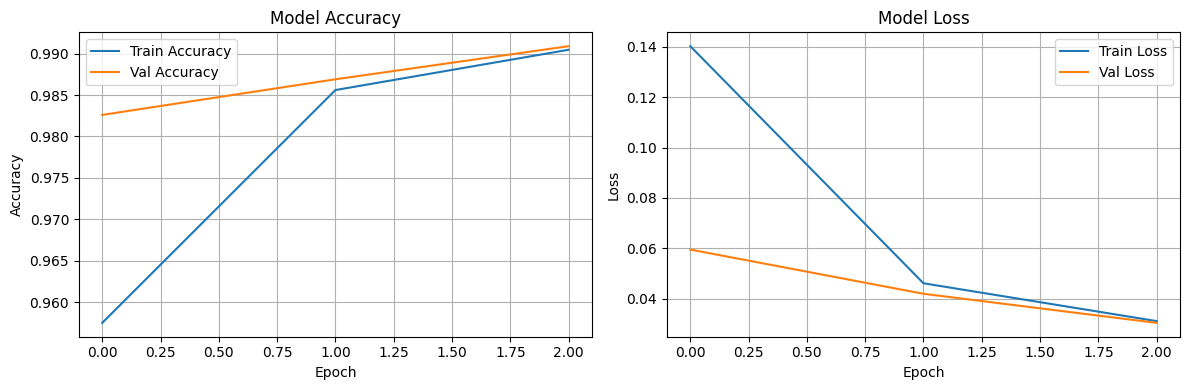

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load and preprocess the data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

# 2. Build the model
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Train the model and save the history (reduced to 3 epochs to avoid timeouts)
print("Training the model for 3 epochs...")
history = model.fit(x_train, y_train, epochs=3, validation_data=(x_test, y_test))

# 4. Plot the training & validation accuracy and loss curves
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


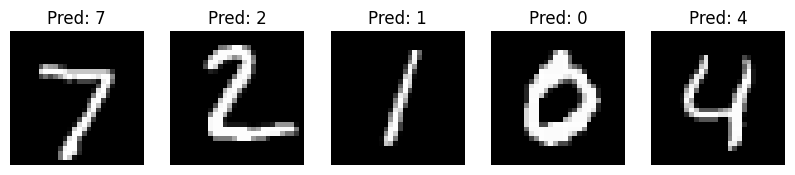

In [5]:
# Display prediction results for the first 5 test images
predictions = model.predict(x_test[:5])

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[i].set_title(f"Pred: {np.argmax(predictions[i])}")
    axes[i].axis('off')
plt.show()

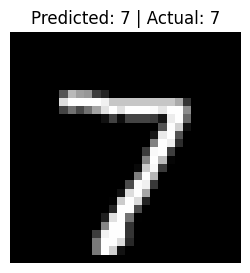

In [6]:
# Interactive testing for a specific test image index
index = 0  # Feel free to change this index to test other images (0 to 9999)
img = x_test[index]
img_batch = np.expand_dims(img, axis=0)
prediction = np.argmax(model.predict(img_batch, verbose=0))

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Predicted: {prediction} | Actual: {y_test[index]}")
plt.axis('off')
plt.show()